In [1]:
from fileformer import FileFormer, ByteLevelTokenizer
import torchac

ninja: no work to do.


In [2]:
import torch
from flax import nnx
import numpy as np
from torchinfo import summary

In [3]:
torch.manual_seed(43)
np.random.seed(43)

In [4]:
ff = FileFormer(257, 256, 4, 4, 0.0)

In [5]:
ff.load_state_dict(torch.load("/Users/daniilogorodnikov/PycharmProjects/Notus/model_flash_epoch_9.pt", map_location="cpu")['model_state_dict'])
ff.eval()

FileFormer(
  (embedding): Embedding(257, 256)
  (positional_encoding): RotaryPositionalEmbeddings()
  (transformer_blocks): ModuleList(
    (0-3): 4 x FileFormerBlock(
      (mha): MultiHeadAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (fc_out): Linear(in_features=256, out_features=257, bias=True)
  (dropout): Dropout(p=0.0, inpla

In [6]:
tokenizer = ByteLevelTokenizer()

In [7]:
with open('enwik8', 'rb') as f:
    data_f = f.read(1024).hex()

In [8]:
_tgt = torch.tensor(tokenizer.encode(data_f), dtype=torch.long)

In [9]:
_tgt[:1]

tensor([62])

In [10]:
_tgt[:-1]

tensor([ 62, 111, 103,  ...,  62,  49, 112])

In [11]:
next_candidate = ff.forward(_tgt[:-1].unsqueeze(0))

In [12]:
import torch.nn.functional as F

In [13]:
def normalize_probabilities(logits, min_prob=1e-6, temperature=2.0):
    """
    Нормализует логиты в вероятности с контролем минимальной вероятности и температуры.

    Параметры:
    ----------
    logits : torch.Tensor
        Тензор сырых оценок формы (..., vocab_size).
    min_prob : float, optional (default=1e-5)
        Минимальная вероятность для каждого элемента после нормализации.
        Должно быть строго меньше 1 / vocab_size.
    temperature : float, optional (default=1.0)
        Температура softmax. Значения >1 делают распределение более равномерным,
        значения <1 — более острым. Используйте >1 для исправления «взрывной» вероятности.

    Возвращает:
    -----------
    torch.Tensor
        Тензор вероятностей той же формы, что и logits. Каждый элемент >= min_prob,
        сумма по последней оси равна 1, все значения < 1.
    """
    # Шаг 1: Softmax с температурой
    scaled_logits = logits / temperature
    probs = F.softmax(scaled_logits, dim=-1)

    vocab_size = probs.shape[-1]
    if min_prob * vocab_size >= 1.0:
        raise ValueError(f"min_prob ({min_prob}) слишком велико для vocab_size={vocab_size}. "
                         f"Необходимо min_prob < 1/{vocab_size}")

    # Шаг 2: Поднимаем все вероятности до min_prob, сохраняя сумму = 1
    # new_p = (1 - n*min_prob) * p + min_prob
    alpha = 1 - vocab_size * min_prob
    new_probs = alpha * probs + min_prob

    # Небольшая перенормировка для борьбы с погрешностями округления
    new_probs = new_probs / new_probs.sum(dim=-1, keepdim=True)


    return new_probs

In [14]:
norm_prob = normalize_probabilities(next_candidate, temperature=2.0)

In [15]:
import constriction
from typing import List
import torch
import numpy as np

message_encoder = constriction.stream.stack.AnsCoder()
# или для порядка FIFO (важно для авторегрессии!):
message_encoder = constriction.stream.queue.RangeEncoder()

In [16]:
_tgt[:-1].shape

torch.Size([1023])

In [17]:
_tgt[:-1].shape

torch.Size([1023])

In [18]:
norm_prob[0][1].max()

tensor(0.5630, grad_fn=<MaxBackward1>)

In [19]:
_tgt[:-1]

tensor([ 62, 111, 103,  ...,  62,  49, 112])

In [20]:
context = torch.tensor([62], dtype=torch.long)

for i in range(len(_tgt)):
    # Получаем распределение для следующего токена на основе текущего контекста
    with torch.no_grad():
        logits = ff.forward(context.unsqueeze(0))   # shape (1, seq_len, vocab_size)
        # Берём предсказание для последней позиции (следующий токен)
        probs = normalize_probabilities(logits[0, -1, :], temperature=5.0)
    prob_np = probs.cpu().numpy().astype(np.float32)
    model = constriction.stream.model.Categorical(prob_np, perfect=False)

    sym = _tgt[i].item()   # текущий символ для кодирования
    message_encoder.encode(sym, model)

    # Обновляем контекст: добавляем реальный символ
    context = torch.cat([context, torch.tensor([sym])])

In [21]:
compressed = message_encoder.get_compressed()

In [22]:
compressed

array([1142862239, 2944500492, 2172013467,  867670855, 2328313608,
       1570955556, 2969285560, 1388116719, 3007959239, 1924114711,
        636591106,  600484632,  765914611, 3157010939, 3873179941,
       3781418374, 3897232422,  561587276, 2656618893, 3861449154,
       2745077529,  437314102, 3341268920, 3496014828, 2019724436,
        866750312, 4078811478, 3724967030, 1776514763, 3938916694,
       1201281977,   75131287, 1083011680,  307848581, 1417812005,
       1877422171, 1337032227,  888414365, 1059587166, 2035708164,
        649659887, 2957099394, 2649882340, 2763337779, 3915927460,
        778099496, 4264227740, 1323829092, 2569645744, 3083479303,
       1403860223, 3524723029, 4230053516, 2060446412,  885179112,
       1088249588, 1697532764, 3343307153,  276693111, 3685432212,
       3383596181,  968675981, 1505067872, 1702777819, 2975588302,
       2194906272, 1296432487, 2122778565, 3604224725,  545760624,
       1288726054, 3750503175, 1613796514, 1144326913, 2902627

In [23]:
message_decoder = constriction.stream.queue.RangeDecoder(compressed)

In [24]:
context = torch.tensor([62], dtype=torch.long)
reconstructed = []

In [40]:
len(_tgt)

1024

In [25]:
for _ in range(len(_tgt)):   # декодируем ровно столько символов, сколько было
    with torch.no_grad():
        logits = ff.forward(context.unsqueeze(0))
        probs = normalize_probabilities(logits[0, -1, :], temperature=5.0)
    prob_np = probs.cpu().numpy().astype(np.float32)
    model = constriction.stream.model.Categorical(prob_np, perfect=False)

    sym = message_decoder.decode(model)
    reconstructed.append(sym)
    context = torch.cat([context, torch.tensor([sym])])

In [38]:
reconstructed

[62,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 34,
 122,
 111,
 110,
 112,
 117,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 48,
 113,
 116,
 105,
 49,
 122,
 111,
 110,
 49,
 103,
 122,
 114,
 113,
 116,
 118,
 47,
 50,
 48,
 53,
 49,
 36,
 34,
 122,
 111,
 110,
 112,
 117,
 60,
 122,
 117,
 107,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 121,
 53,
 48,
 113,
 116,
 105,
 49,
 52,
 50,
 50,
 51,
 49,
 90,
 79,
 78,
 85,
 101,
 106,
 103,
 111,
 99,
 47,
 107,
 112,
 117,
 118,
 99,
 112,
 101,
 103,
 36,
 34,
 122,
 117,
 107,
 60,
 117,
 101,
 106,
 103,
 111,
 99,
 78,
 113,
 101,
 99,
 118,
 107,
 113,
 112,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 48,
 113,
 116,
 105,
 49,
 122,
 111,
 110,
 49,
 103,
 122,
 114,
 113,
 116,
 118,
 47,
 50,
 48,
 53,
 49,
 34,
 106,
 118,
 1

In [39]:
context

tensor([ 62,  62, 111,  ...,  49, 112,  99])

In [28]:
context[1:].tolist() == _tgt.tolist()

True

In [27]:
_tgt.tolist()

[62,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 34,
 122,
 111,
 110,
 112,
 117,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 48,
 113,
 116,
 105,
 49,
 122,
 111,
 110,
 49,
 103,
 122,
 114,
 113,
 116,
 118,
 47,
 50,
 48,
 53,
 49,
 36,
 34,
 122,
 111,
 110,
 112,
 117,
 60,
 122,
 117,
 107,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 121,
 53,
 48,
 113,
 116,
 105,
 49,
 52,
 50,
 50,
 51,
 49,
 90,
 79,
 78,
 85,
 101,
 106,
 103,
 111,
 99,
 47,
 107,
 112,
 117,
 118,
 99,
 112,
 101,
 103,
 36,
 34,
 122,
 117,
 107,
 60,
 117,
 101,
 106,
 103,
 111,
 99,
 78,
 113,
 101,
 99,
 118,
 107,
 113,
 112,
 63,
 36,
 106,
 118,
 118,
 114,
 60,
 49,
 49,
 121,
 121,
 121,
 48,
 111,
 103,
 102,
 107,
 99,
 121,
 107,
 109,
 107,
 48,
 113,
 116,
 105,
 49,
 122,
 111,
 110,
 49,
 103,
 122,
 114,
 113,
 116,
 118,
 47,
 50,
 48,
 53,
 49,
 34,
 106,
 118,
 1

In [45]:
probs.numpy().shape

(257,)

In [29]:
import struct
import numpy as np
header = struct.pack('<I', len(compressed))      # 4 байта, little-endian
data   = compressed.astype('<u4').tobytes()      # little-endian uint32

In [30]:
header

b'\xa3\x00\x00\x00'

In [31]:
len(data.hex())

1304

In [32]:
len(data_f)

2048

In [33]:
np.frombuffer(data, dtype='<u4')

array([1142862239, 2944500492, 2172013467,  867670855, 2328313608,
       1570955556, 2969285560, 1388116719, 3007959239, 1924114711,
        636591106,  600484632,  765914611, 3157010939, 3873179941,
       3781418374, 3897232422,  561587276, 2656618893, 3861449154,
       2745077529,  437314102, 3341268920, 3496014828, 2019724436,
        866750312, 4078811478, 3724967030, 1776514763, 3938916694,
       1201281977,   75131287, 1083011680,  307848581, 1417812005,
       1877422171, 1337032227,  888414365, 1059587166, 2035708164,
        649659887, 2957099394, 2649882340, 2763337779, 3915927460,
        778099496, 4264227740, 1323829092, 2569645744, 3083479303,
       1403860223, 3524723029, 4230053516, 2060446412,  885179112,
       1088249588, 1697532764, 3343307153,  276693111, 3685432212,
       3383596181,  968675981, 1505067872, 1702777819, 2975588302,
       2194906272, 1296432487, 2122778565, 3604224725,  545760624,
       1288726054, 3750503175, 1613796514, 1144326913, 2902627

In [34]:
import matplotlib.pyplot as plt

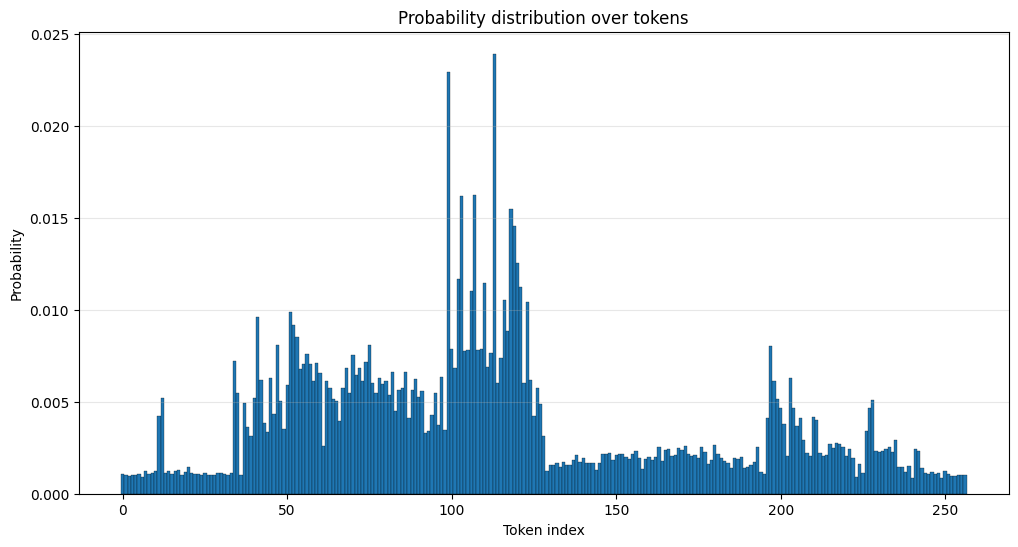

In [37]:
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму
plt.bar(range(len(probs.numpy())), normalize_probabilities(logits[0, -1, :], temperature=10.0).numpy(), width=1.0, edgecolor='black', linewidth=0.2)

# Настройки
plt.xlabel('Token index')
plt.ylabel('Probability')
plt.title('Probability distribution over tokens')
plt.grid(axis='y', alpha=0.3)